In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tensorflow as tf
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from tensorflow import keras
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers
warnings.filterwarnings('ignore')

In [5]:
IMAGE_SIZE = (224,224)
BATCH_SIZE = 64
SEED = 123
AUTOTUNE = tf.data.AUTOTUNE
VALIDATION_SPLIT = 0.2

DATA = '/kaggle/input/datasets/prasunroy/natural-images/natural_images/'

training_dataset,val_and_test_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA,
    validation_split = VALIDATION_SPLIT,
    subset = 'both',
    shuffle = True,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    seed = SEED
)
    
class_names = training_dataset.class_names

total_batches = len(val_and_test_dataset)
val_size = total_batches // 2
validation_dataset = val_and_test_dataset.take(val_size)
testing_dataset = val_and_test_dataset.skip(val_size)

train_ds = training_dataset.cache().shuffle(1000).prefetch(buffer_size = AUTOTUNE)
val_ds = validation_dataset.cache().prefetch(buffer_size = AUTOTUNE)
test_ds = testing_dataset.cache().prefetch(buffer_size = AUTOTUNE)

print(f"Training Dataset Batches: {len(train_ds)}")
print(f"Validation Dataset Batches: {len(val_ds)}")
print(f"Testing Dataset Batches: {len(test_ds)}")
print("Dataset Loading and Spliting Complete!")

Found 6899 files belonging to 8 classes.
Using 5520 files for training.
Using 1379 files for validation.
Training Dataset Batches: 87
Validation Dataset Batches: 11
Testing Dataset Batches: 11
Dataset Loading and Spliting Complete!


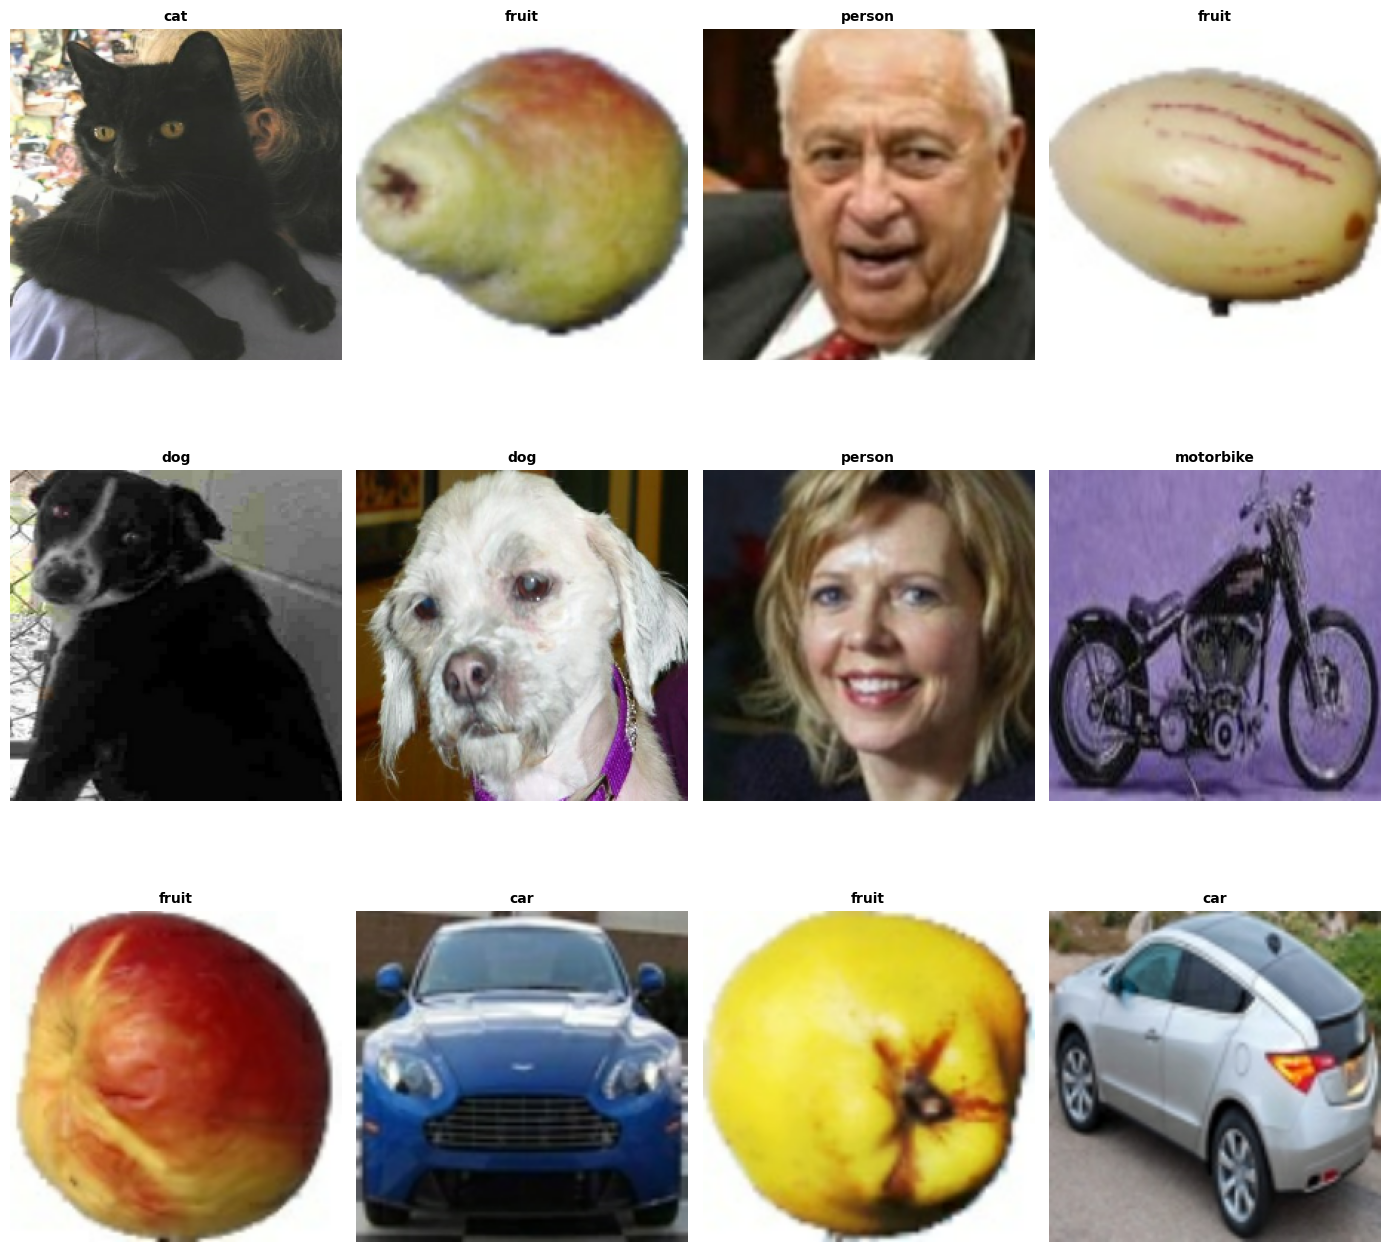

In [6]:
for images,labels in train_ds.take(1):
    plt.figure(figsize = (14,14))
    for img in range(12):
        plt.subplot(3,4,img + 1)
        plt.title(class_names[labels[img]],fontsize = 10,fontweight = 'bold')
        plt.imshow(images[img].numpy().astype('uint8'))
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close()

In [29]:
base_model = VGG16(
    input_shape = (224,224,3),
    include_top = False,
    weights = 'imagenet'
)
base_model.trainable = False

model = Sequential()

In [30]:
model.add(layers.Input(shape = (224,224,3)))

model.add(layers.RandomFlip('horizontal'))
model.add(layers.RandomRotation(0.2))
model.add(layers.RandomZoom(0.3))
model.add(layers.RandomContrast(0.2))

model.add(layers.Lambda(tf.keras.applications.vgg16.preprocess_input))
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())

model.add(layers.Dense(256,activation = 'relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.3))
model.add(layers.Dense(8,activation = 'softmax'))

model.summary()

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-4),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
early = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True,
    verbose = 1
)
print("Model Training Start...")
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 10,
    callbacks = [early]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849,096 (56.64 MB)

 Trainable params: 133,896 (523.03 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

Model Training Start...
Epoch 1/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 33s 355ms/step - accuracy: 0.5281 - loss: 1.5132 - val_accuracy: 0.9403 - val_loss: 0.2351
Epoch 2/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 30s 345ms/step - accuracy: 0.8989 - loss: 0.3629 - val_accuracy: 0.9830 - val_loss: 0.0795
Epoch 3/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 29s 331ms/step - accuracy: 0.9397 - loss: 0.2167 - val_accuracy: 0.9901 - val_loss: 0.0479
Epoch 4/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 30s 342ms/step - accuracy: 0.9585 - loss: 0.1596 - val_accuracy: 0.9943 - val_loss: 0.0348
Epoch 5/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 29s 339ms/step - accuracy: 0.9645 - loss: 0.1272 - val_accuracy: 0.9943 - val_loss: 0.0276
Epoch 6/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 29s 337ms/step - accuracy: 0.9719 - loss: 0.1036 - val_accuracy: 0.9957 - val_loss: 0.0229
Epoch 7/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 29s 338ms/step - accuracy: 0.9743 - loss: 0.0920 - val_accuracy: 0.9929 - val_loss: 0.0212
Epoch 8/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 29s 339ms/step - accuracy: 0.9792 -

In [31]:
test_result = model.evaluate(test_ds)
print(f"Testing Loss: {test_result[0]:.2f}")
print(f"Testing Accuracy: {test_result[1] * 100:.2f}%")


11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 289ms/step - accuracy: 0.9941 - loss: 0.0184
Testing Loss: 0.02
Testing Accuracy: 99.41%


In [32]:
train_result = model.evaluate(train_ds)
print(f"Training Loss: {train_result[0]:.2f}")
print(f"Training Accuracy: {train_result[1] * 100:.2f}%")


87/87 ━━━━━━━━━━━━━━━━━━━━ 26s 296ms/step - accuracy: 0.9975 - loss: 0.0121
Training Loss: 0.01
Training Accuracy: 99.75%


In [33]:
val_result = model.evaluate(val_ds)
print(f"Validation Loss: {val_result[0]:.2f}")
print(f"Validation Accuracy: {val_result[1] * 100:.2f}%")


11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 300ms/step - accuracy: 0.9972 - loss: 0.0165
Validation Loss: 0.02
Validation Accuracy: 99.72%


In [34]:
y_true = np.concatenate([y for x,y in test_ds],axis = 0)
y_pred_proba = model.predict(test_ds)
y_pred = np.argmax(y_pred_proba,axis = 1)
print(f"Accuracy Score: {accuracy_score(y_true,y_pred) * 100:.2f}%")
print("\nClassification Report:\n",classification_report(y_true,y_pred))
print("\nConfusion Matrix:\n",confusion_matrix(y_true,y_pred))

11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 308ms/step
Accuracy Score: 99.41%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        66
           1       1.00      1.00      1.00        96
           2       0.98      0.99      0.98        84
           3       0.97      0.97      0.97        71
           4       1.00      1.00      1.00        95
           5       1.00      1.00      1.00        94
           6       1.00      1.00      1.00        69
           7       1.00      1.00      1.00       100

    accuracy                           0.99       675
   macro avg       0.99      0.99      0.99       675
weighted avg       0.99      0.99      0.99       675


Confusion Matrix:
 [[ 65   0   0   1   0   0   0   0]
 [  0  96   0   0   0   0   0   0]
 [  0   0  83   1   0   0   0   0]
 [  0   0   2  69   0   0   0   0]
 [  0   0   0   0  95   0   0   0]
 [  0   0   0   0   0  94   0   0]
 [  0   0   0   0   0   0  69 

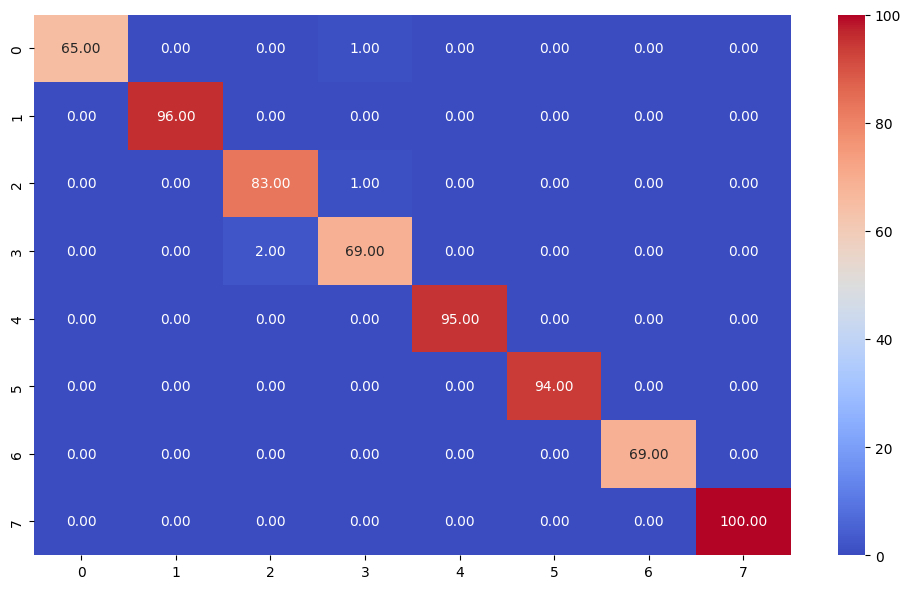

In [35]:
x = confusion_matrix(y_true,y_pred)
plt.figure(figsize = (10,6))
sns.heatmap(x,annot = True,fmt = '.2f',cmap = 'coolwarm')
plt.tight_layout()
plt.show()

In [36]:
model.save('natural_images_classification.h5')
print("Model Saved Complete!")

Model Saved Complete!
